### [Enhancing Traditional k-Means for More Accurate Market Regime Detection](https://medium.com/@amina.kaltayeva/market-regime-detection-why-understanding-ml-algorithms-matters-4eb7e8cac755)

> Wasserstein k-means (WK-means)

In [1]:
!pip install -q POT

In [2]:
import ot
import numpy as np

class WKMeans:
    def __init__(self, k, p=1, tolerance=1e-4, max_iter=100, seed=42):
        """
        Wasserstein K-means algorithm.

        Parameters:
        - k: Number of clusters
        - p: Order of the Wasserstein distance
        - tolerance: Convergence threshold
        - max_iter: Maximum number of iterations
        """
        self.k = k
        self.p = p
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.seed = seed
        self.centroids = None

    def wasserstein_distance(self, mu1, mu2):
        """Compute the p-Wasserstein distance between two empirical distributions."""
        n = len(mu1)
        a = np.ones(n) / n
        M = ot.dist(mu1.reshape(-1, 1), mu2.reshape(-1, 1), metric="minkowski", p=self.p)
        return ot.emd2(a, a, M)

    def wasserstein_barycenter(self, cluster_samples):
        """Compute the Wasserstein barycenter (median of sorted distributions)."""
        sorted_samples = np.sort(cluster_samples, axis=0)
        return np.median(sorted_samples, axis=0)

    def fit(self, samples):
        """
        Fit the WK-means clustering algorithm.

        Parameters:
        - samples: List of empirical distributions (numpy arrays)
        """
        # Initialize centroids by randomly selecting k samples
        np.random.seed(self.seed)
        self.centroids = [samples[i] for i in np.random.choice(len(samples), self.k, replace=False)]

        for _ in range(self.max_iter):
            clusters = {i: [] for i in range(self.k)}

            # Assign each sample to the closest centroid
            for sample in samples:
                distances = [self.wasserstein_distance(sample, centroid) for centroid in self.centroids]
                closest_cluster = np.argmin(distances)
                clusters[closest_cluster].append(sample)

            # Update centroids as Wasserstein barycenters
            new_centroids = []
            for i in range(self.k):
                if clusters[i]:
                    new_centroids.append(self.wasserstein_barycenter(np.array(clusters[i])))
                else:
                    new_centroids.append(self.centroids[i])  # Keep previous centroid if no samples assigned

            # Compute loss function (sum of Wasserstein distances)
            loss = sum(self.wasserstein_distance(self.centroids[i], new_centroids[i]) for i in range(self.k))

            # Check convergence
            if loss < self.tolerance:
                break

            self.centroids = new_centroids

    def predict(self, samples):
        """
        Predict the cluster for each sample.

        Parameters:
        - samples: List of empirical distributions (numpy arrays)

        Returns:
        - List of cluster indices
        """
        return [np.argmin([self.wasserstein_distance(sample, centroid) for centroid in self.centroids]) for sample in samples]

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from IPython.display import display
## from wkmeans import WKMeans

# Parameters

# 1. Data range
ticker_period = '5y'

# 2. Tickers
crypto_tickers = ['BTC-USD', 'ETH-USD', 'BNB-USD']

# 3. The number of clusters
k = 3

# Data upload
df = yf.download(crypto_tickers, period = ticker_period, auto_adjust=True, progress=False)
print(f"Total records: {df.shape}")

display(df.sample(20))

Total records: (1827, 15)


Price             Close                                     High  \
Ticker          BNB-USD        BTC-USD      ETH-USD      BNB-USD   
Date                                                               
2023-01-27   308.123108   23078.728516  1598.156494   309.894470   
2021-10-26   478.025055   60363.792969  4131.102051   489.774170   
2021-09-06   495.925018   52633.535156  3928.379395   508.822235   
2021-04-11   525.385559   60204.964844  2157.656982   529.645020   
2025-10-20  1101.061646  110588.929688  3980.760254  1142.744507   
2025-12-11   886.166626   92511.335938  3237.056885   894.658997   
2022-06-05   298.934723   29906.662109  1805.204956   301.940765   
2022-05-15   312.007721   31305.113281  2145.706787   312.176544   
2026-03-05   647.625854   70841.125000  2071.605469   664.643860   
2025-03-02   622.936096   94248.351562  2519.694580   634.542664   
2025-07-14   689.416748  119849.703125  3013.350830   706.713318   
2022-04-10   418.590668   42207.671875  3211.866943   429.364105   
2021-05-01   619.347229   57828.050781  2945.892822   641.860840   
2025-10-08  1306.599365  123354.867188  4527.647949  1332.831543   
2022-04-11   394.086884   39521.902344  2981.052246   419.490784   
2023-10-06   213.555527   27946.597656  1645.831543   214.392960   
2021-12-29   514.000793   46444.710938  3628.531738   540.615784   
2025-10-23  1127.572998  110069.726562  3856.026367  1150.999268   
2025-01-12   693.048279   94488.437500  3265.951172   697.998596   
2024-03-21   553.248230   65491.390625  3492.991211   570.053223   

Price                                           Low                 \
Ticker            BTC-USD      ETH-USD      BNB-USD        BTC-USD   
Date                                                                 
2023-01-27   23417.720703  1617.000854   300.320587   22654.593750   
2021-10-26   63229.027344  4289.131348   475.286285   59991.160156   
2021-09-06   52700.941406  3968.426514   488.678955   51053.679688   
2021-04-11   60790.554688  2165.191406   459.590424   59289.796875   
2025-10-20  111711.031250  4084.159668  1090.006836  107485.015625   
2025-12-11   93554.265625  3327.344482   861.253662   89335.296875   
2022-06-05   30117.744141  1825.859619   295.425262   29574.449219   
2022-05-15   31308.191406  2147.194336   286.643768   29527.740234   
2026-03-05   73555.789062  2163.036133   646.893188   70654.882812   
2025-03-02   95043.437500  2548.811768   602.632996   85040.210938   
2025-07-14  123091.609375  3079.985596   686.828857  118959.195312   
2022-04-10   43376.378906  3303.003174   418.590668   42021.207031   
2021-05-01   58448.339844  2951.440918   611.302002   57052.273438   
2025-10-08  124167.093750  4556.221680  1270.310303  121119.179688   
2022-04-11   42424.589844  3214.461914   392.109924   39373.058594   
2023-10-06   28252.537109  1659.609863   210.557251   27215.552734   
2021-12-29   48119.742188  3827.981934   511.745331   46201.496094   
2025-10-23  111288.593750  3930.974854  1071.939453  107548.429688   
2025-01-12   95367.539062  3298.018311   689.889099   93712.507812   
2024-03-21   68199.992188  3586.905029   541.655090   64580.917969   

Price                           Open                                  Volume  \
Ticker          ETH-USD      BNB-USD        BTC-USD      ETH-USD     BNB-USD   
Date                                                                           
2023-01-27  1565.244995   304.874451   23030.716797  1603.080078   484897937   
2021-10-26  4106.823730   484.706879   63032.761719  4217.337891  1486193826   
2021-09-06  3868.994385   504.698090   51769.003906  3951.520752  2206397359   
2021-04-11  2119.865723   471.646423   59846.230469  2136.156982  5697422904   
2025-10-20  3911.726318  1109.682129  108667.445312  3984.696289  4209252745   
2025-12-11  3149.034424   894.658997   92011.304688  3324.386719  2524483059   
2022-06-05  1777.133301   301.597900   29835.117188  1801.818970   779603321   
2022-05-15  2008.162720 

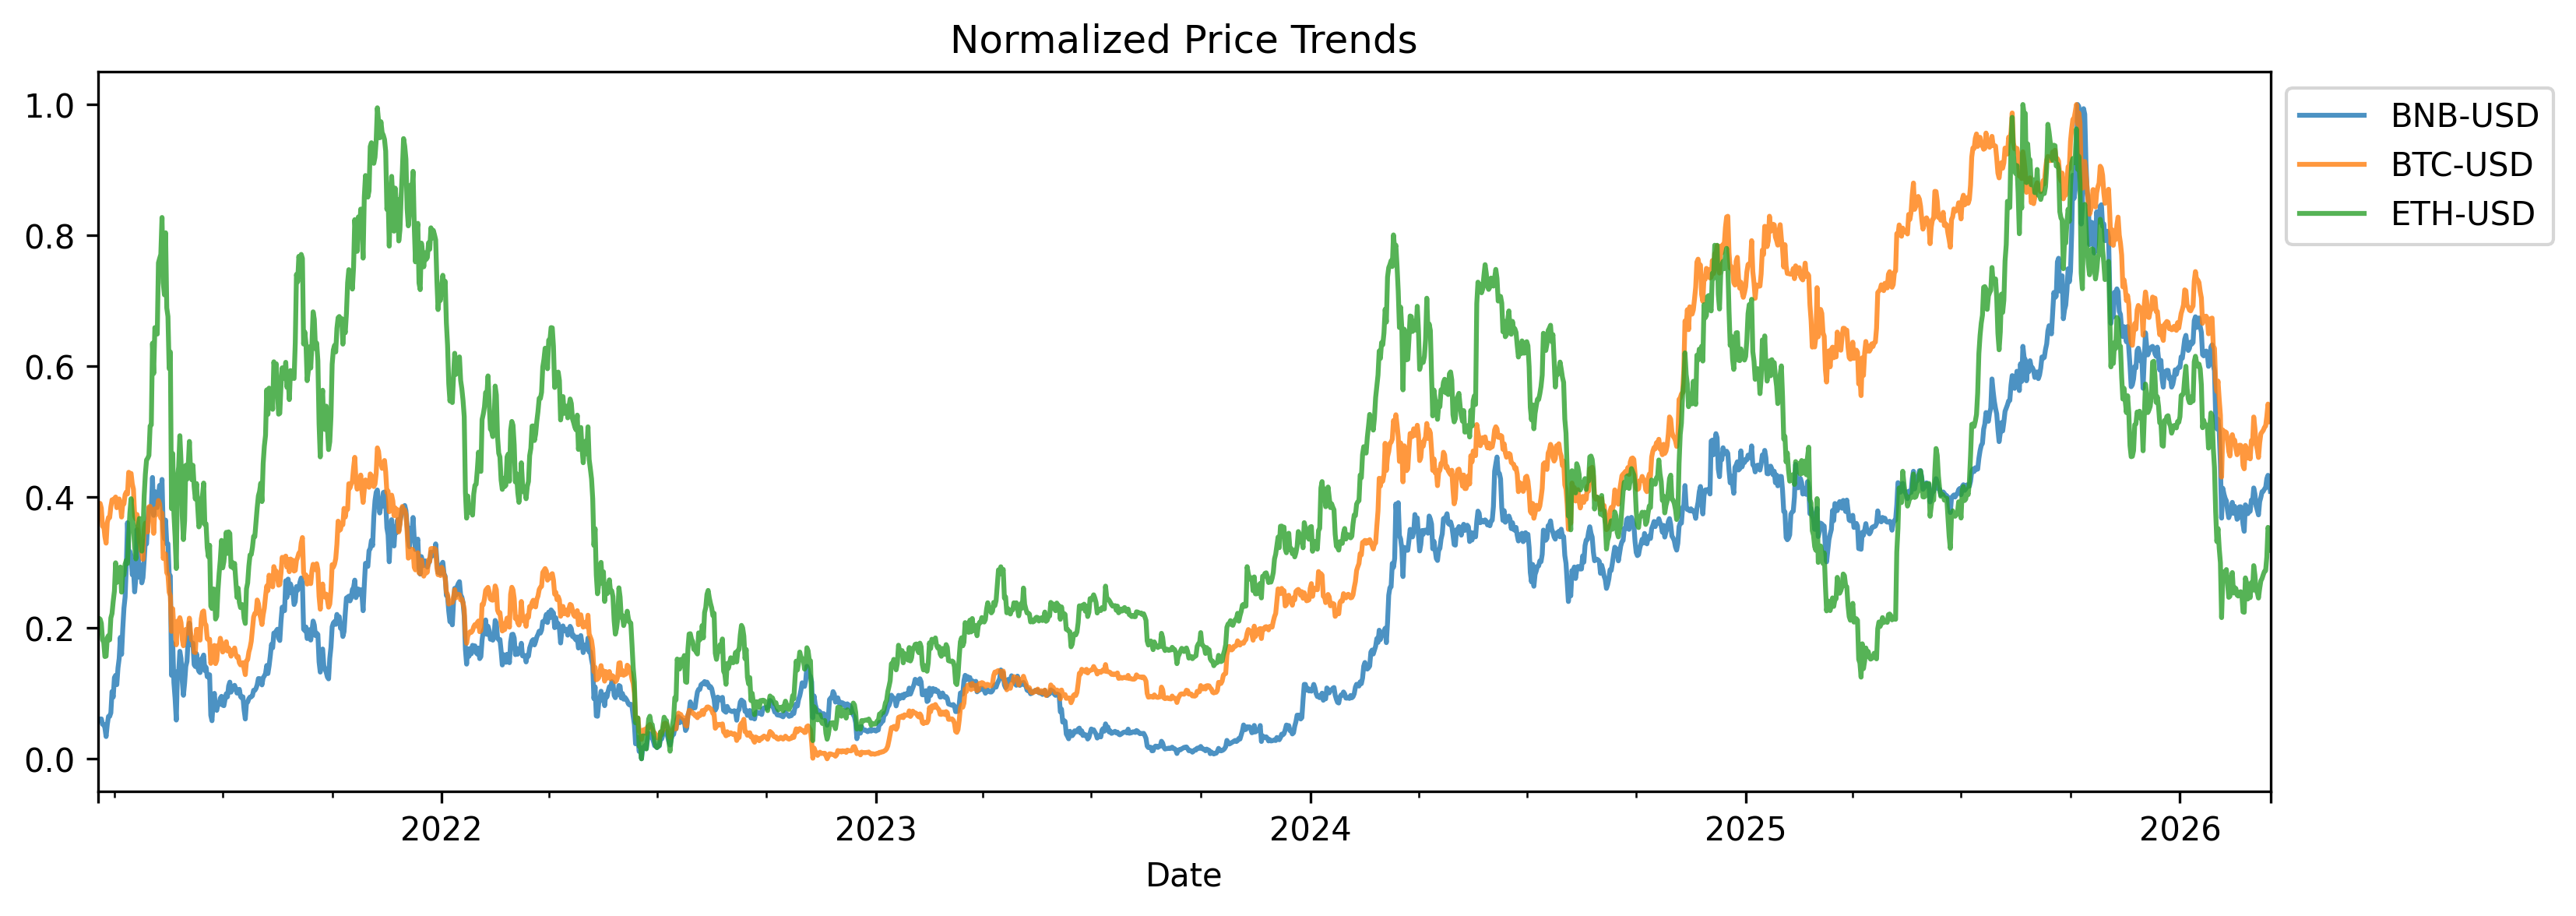

In [4]:
# Trends
df_graph = df[( 'Close',  )].copy()

for col in  df_graph.columns:
    df_graph[col] = (df_graph[col]-df_graph[col].min())/ (df_graph[col].max() - df_graph[col].min())

fig, ax = plt.subplots(dpi=300, figsize=(12, 4))
df_graph.plot(ax=ax,  alpha=0.8)
ax.set_title('Normalized Price Trends')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

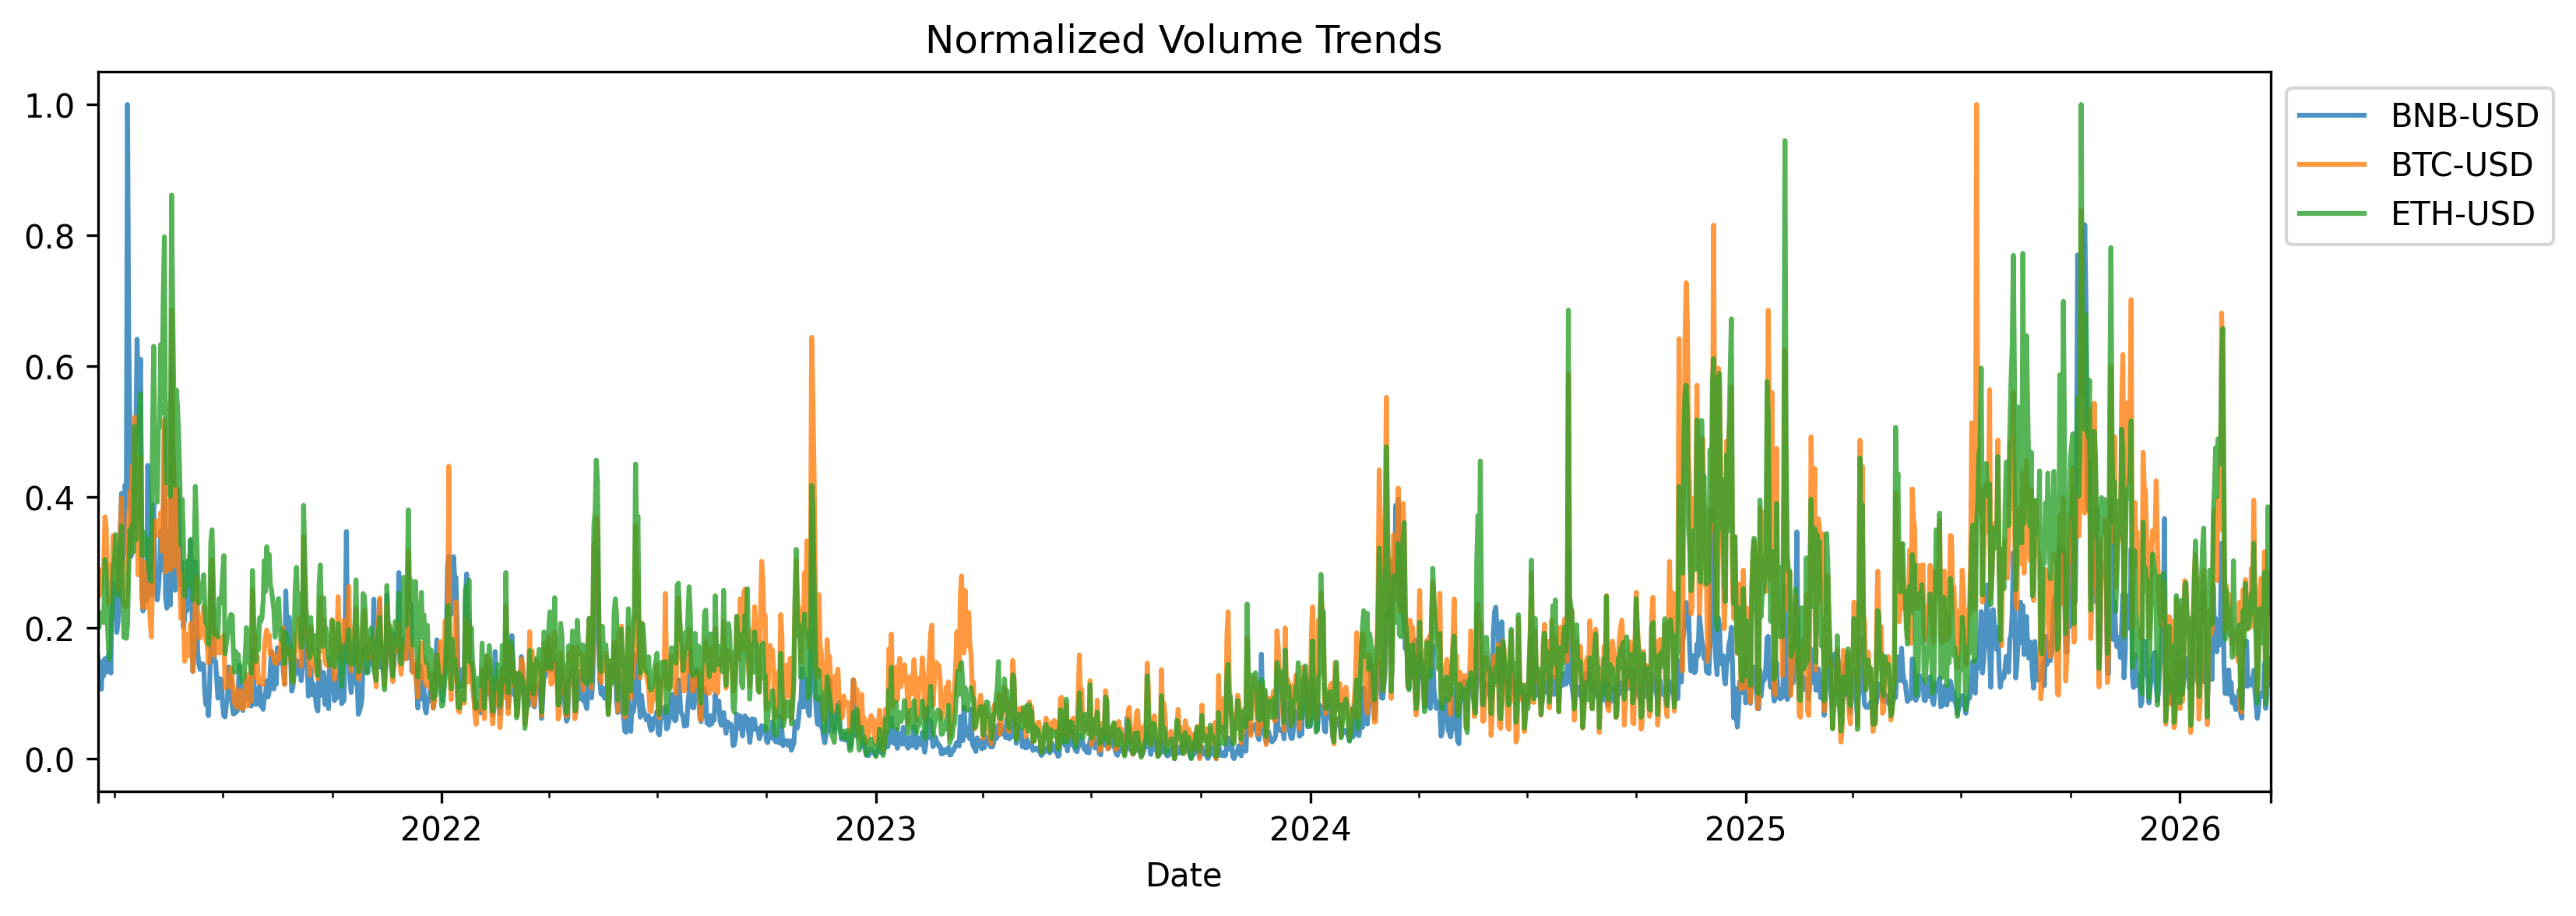

In [5]:
# Trends
df_graph = df[( 'Volume',  )].copy()

for col in  df_graph.columns:
    df_graph[col] = (df_graph[col]-df_graph[col].min())/ (df_graph[col].max() - df_graph[col].min())

fig, ax = plt.subplots(dpi=300, figsize=(12, 4))
df_graph.plot(ax=ax,  alpha=0.8)
ax.set_title('Normalized Volume Trends')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

In [6]:
# Features computation
df_features = pd.DataFrame(index=df.index)

# 1. Returns
for ticker in crypto_tickers:
    df_features[( 'Returns',  ticker)] = np.log(df[( 'Close',  ticker)] / df[( 'Close',  ticker)].shift())

# 2. Volatility and MA
for ticker in crypto_tickers:
    for ma in [5, 10, 15, 30, 60, 180]:
        df_features[( 'MA'+str(ma),  ticker)] = df_features[( 'Returns',   ticker)].rolling(window=ma, min_periods=1).mean()
    for ma in [15, 60, 180]:
        df_features[( 'Volatility'+str(ma),  ticker)] = df_features[( 'Returns',   ticker)].rolling(window=ma, min_periods=1).std()

df_features.columns = pd.MultiIndex.from_tuples(df_features.columns, names=('feature', 'ticker'))
df_features = df_features.dropna()

In [7]:
# Define dataset
dataset = df_features.values

# Run k-means
kmeans = KMeans(n_clusters=k)
kmeans.fit(dataset)

# Run WK-mean
wkmeans = WKMeans(k=k)
wkmeans.fit(dataset)

# Predict cluster assignments
df_features['cluster'] = kmeans.predict(dataset).tolist()
df_features['wk'] = wkmeans.predict(dataset)

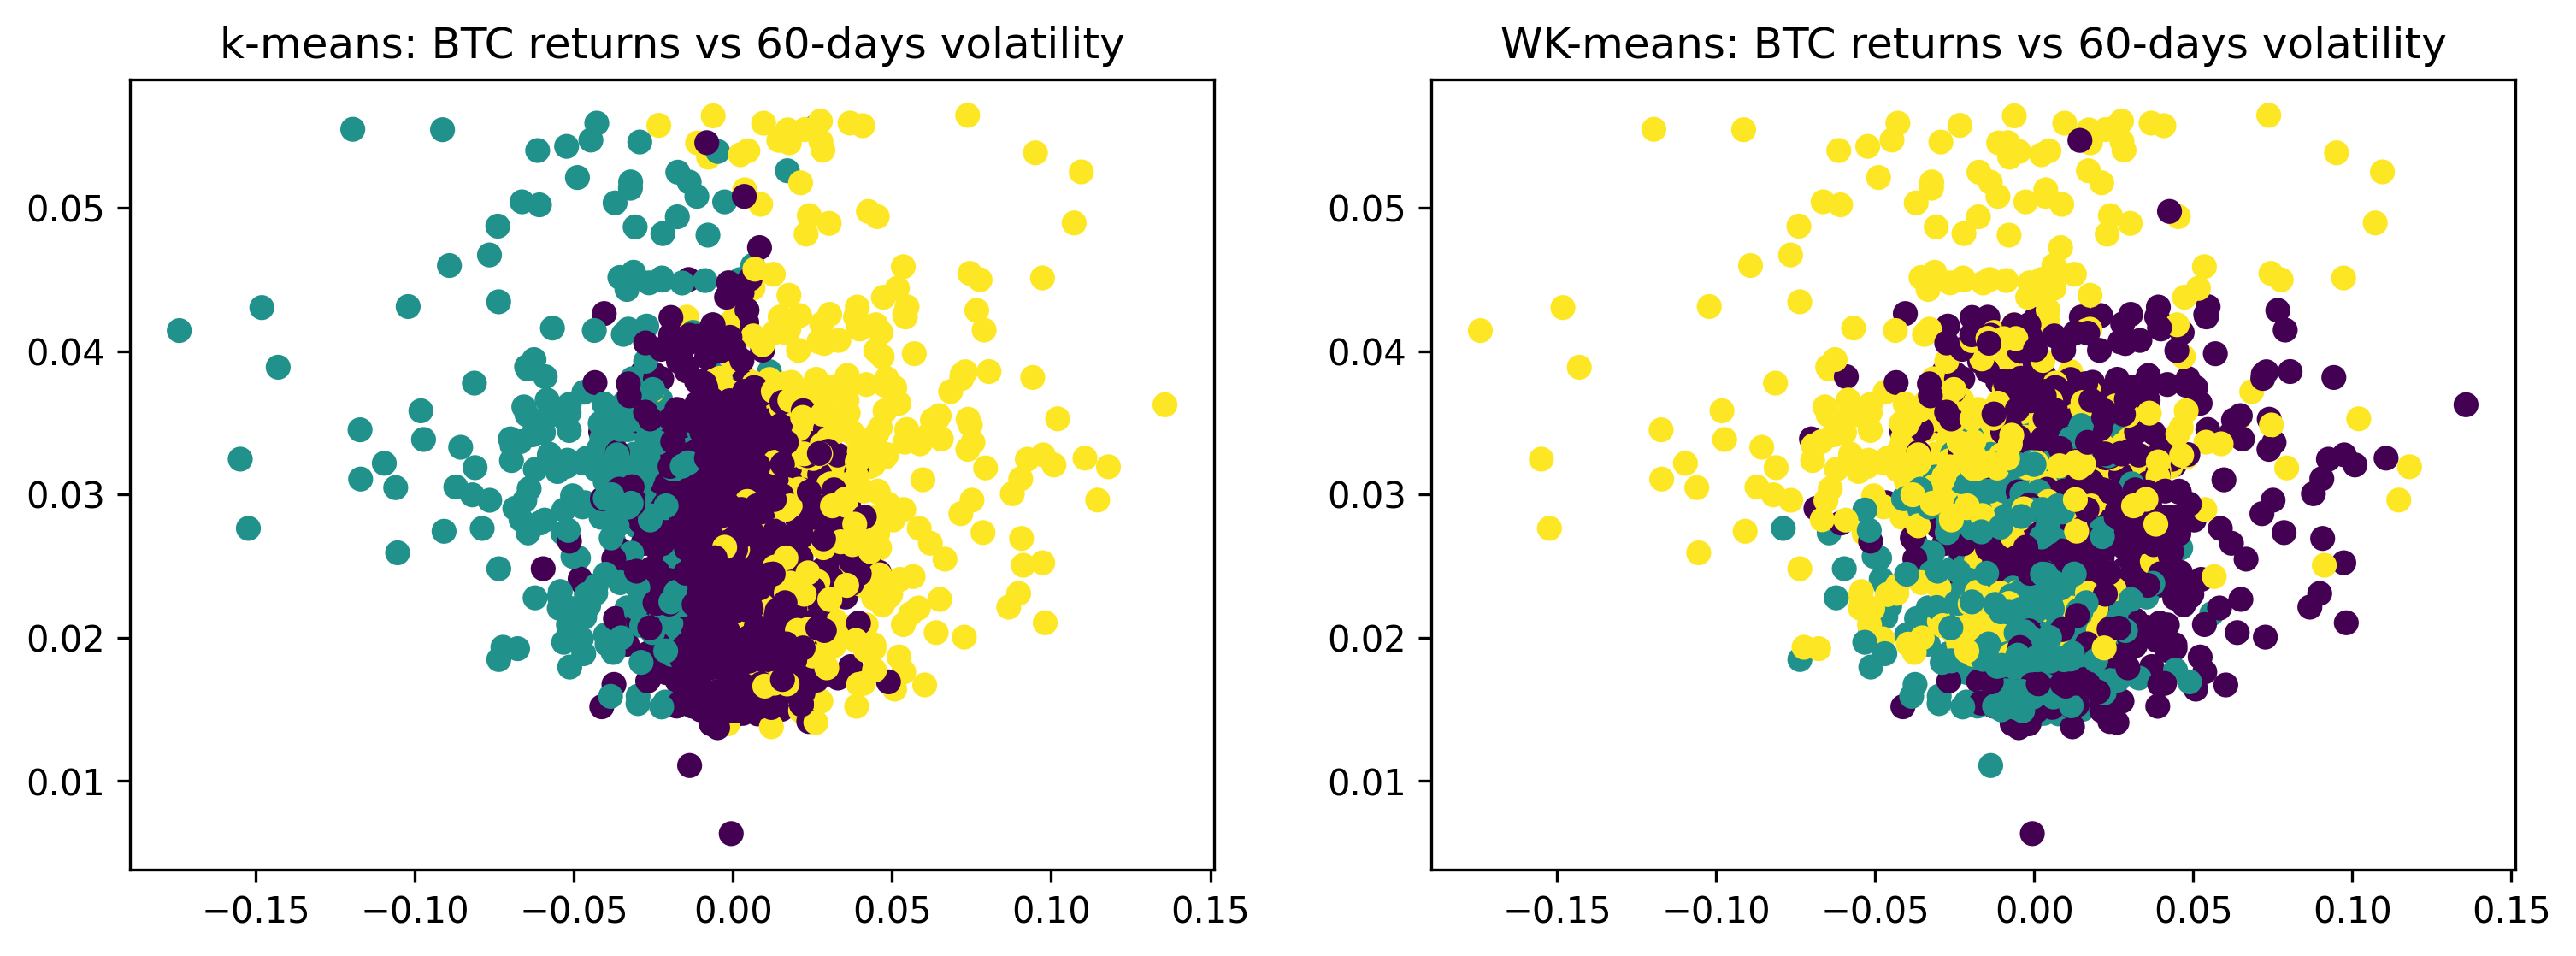

In [8]:
fig, axes = plt.subplots(nrows=1, ncols=2, dpi=300, figsize=(12, 4))

axes[0].scatter(df_features[('Returns', 'BTC-USD')].values,
            df_features[('Volatility60', 'BTC-USD')].values,
            c=df_features['cluster'].values)

axes[0].set_title('k-means: BTC returns vs 60-days volatility')

axes[1].scatter(df_features[('Returns', 'BTC-USD')].values,
            df_features[('Volatility60', 'BTC-USD')].values,
            c=df_features['wk'].values)

axes[1].set_title('WK-means: BTC returns vs 60-days volatility')
plt.show()

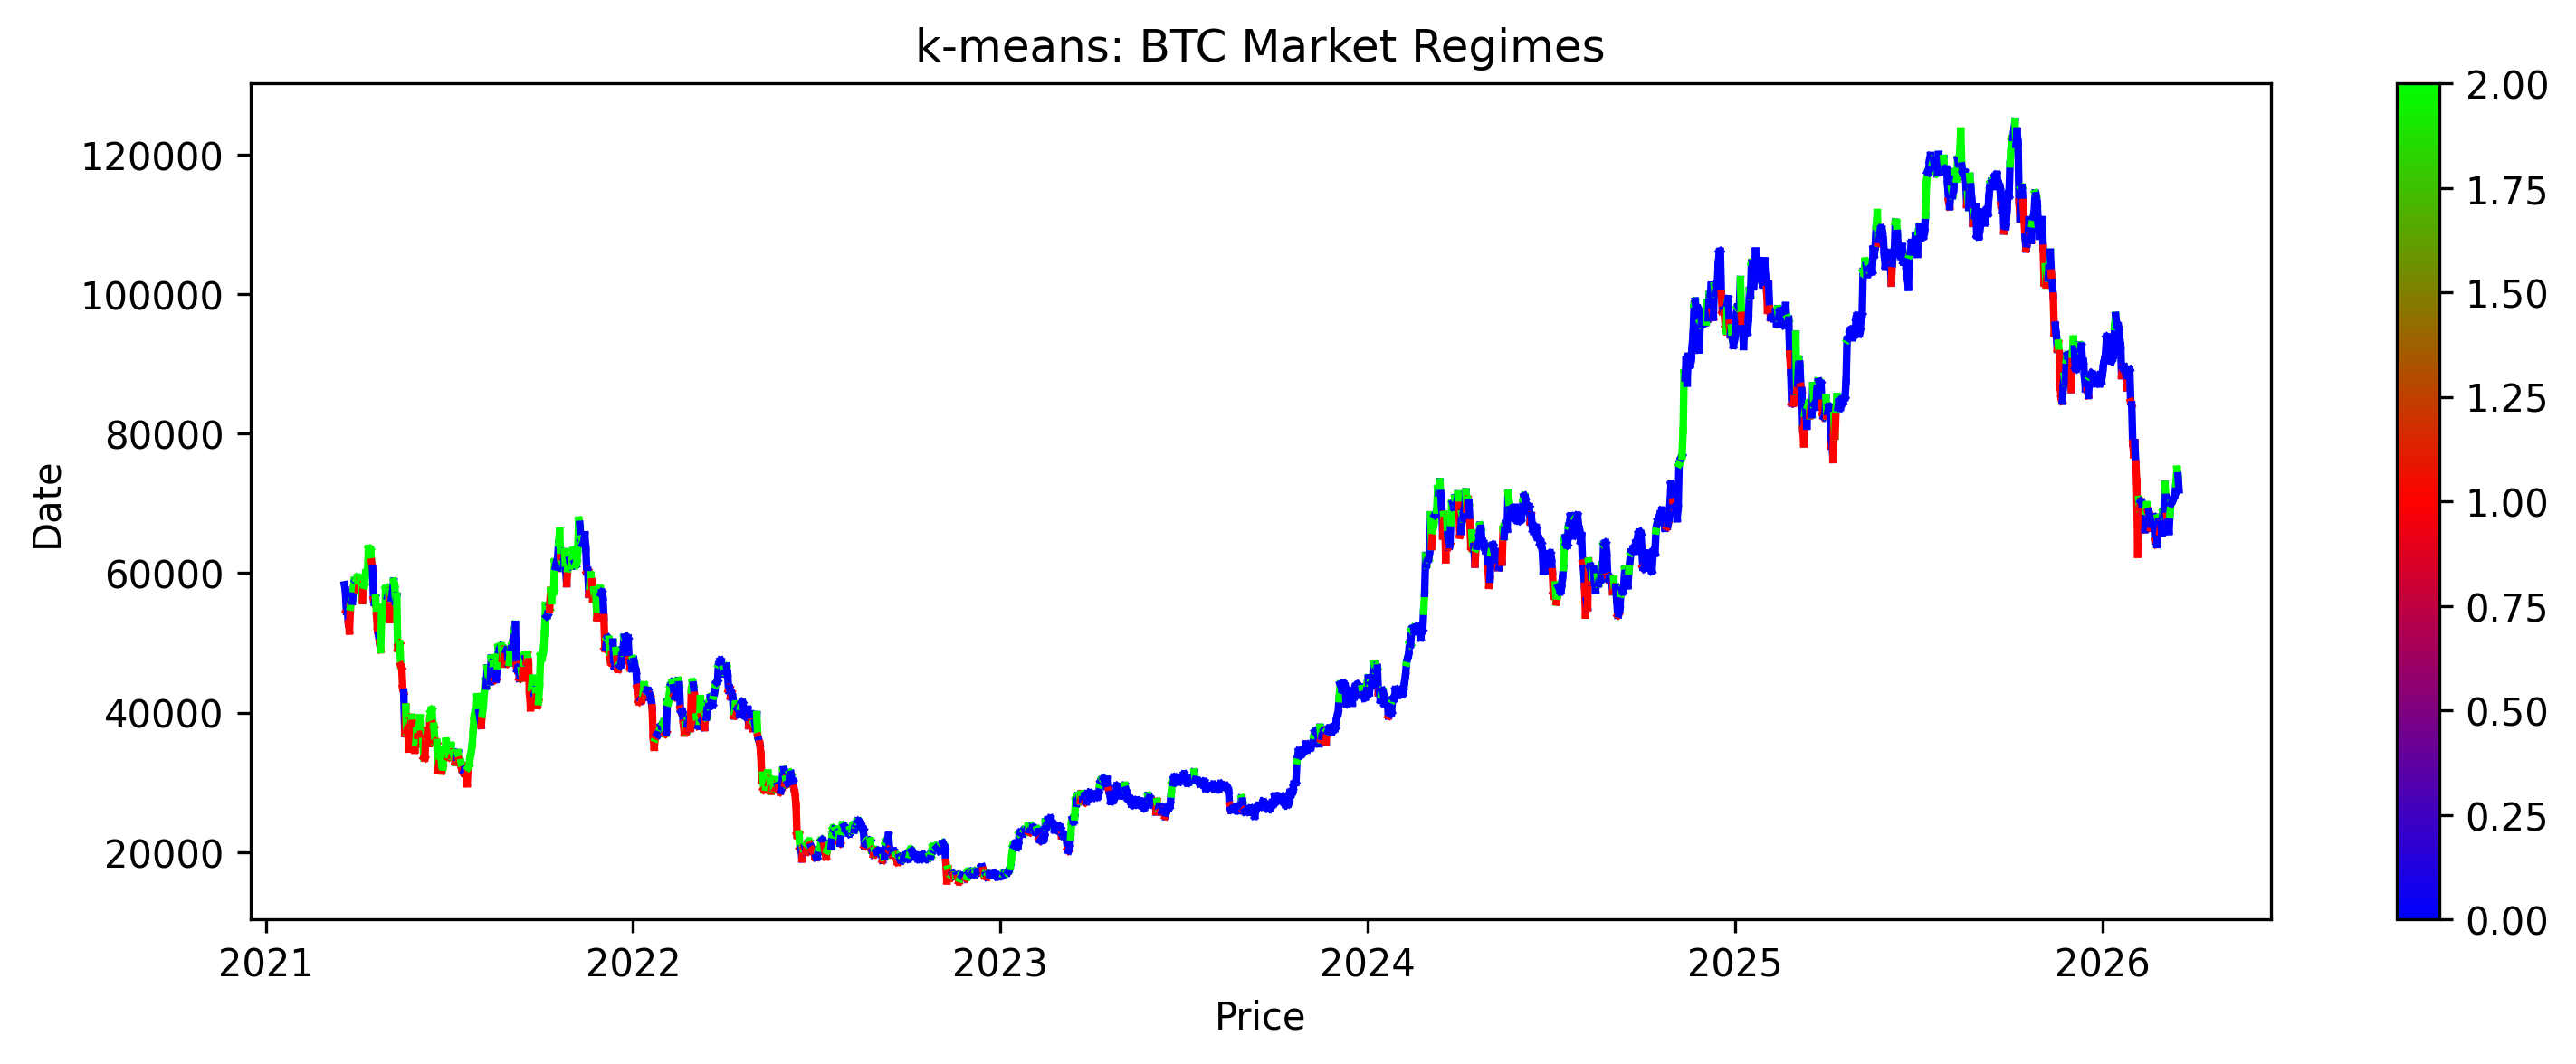

In [9]:
import warnings
warnings.filterwarnings('ignore')

df = pd.concat([df, df_features['cluster']], axis=1)

n = len(df)
# Normalize color values for better visualization
norm = plt.Normalize(df['cluster'].min(), df['cluster'].max())
cmap = plt.cm.brg  # Choose a colormap (e.g., 'viridis', 'coolwarm', 'jet')

# Plot line with dynamic coloring
fig, ax = plt.subplots(dpi=300, figsize=(12, 4))
for i in range(n - 1):
    ax.plot(df[('Close', 'BTC-USD')][i:i+2], color=cmap(norm(df['cluster'][i])), linewidth=2)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)

# Labels and title
ax.set_xlabel("Price")
ax.set_ylabel("Date")
ax.set_title("k-means: BTC Market Regimes")

plt.show()

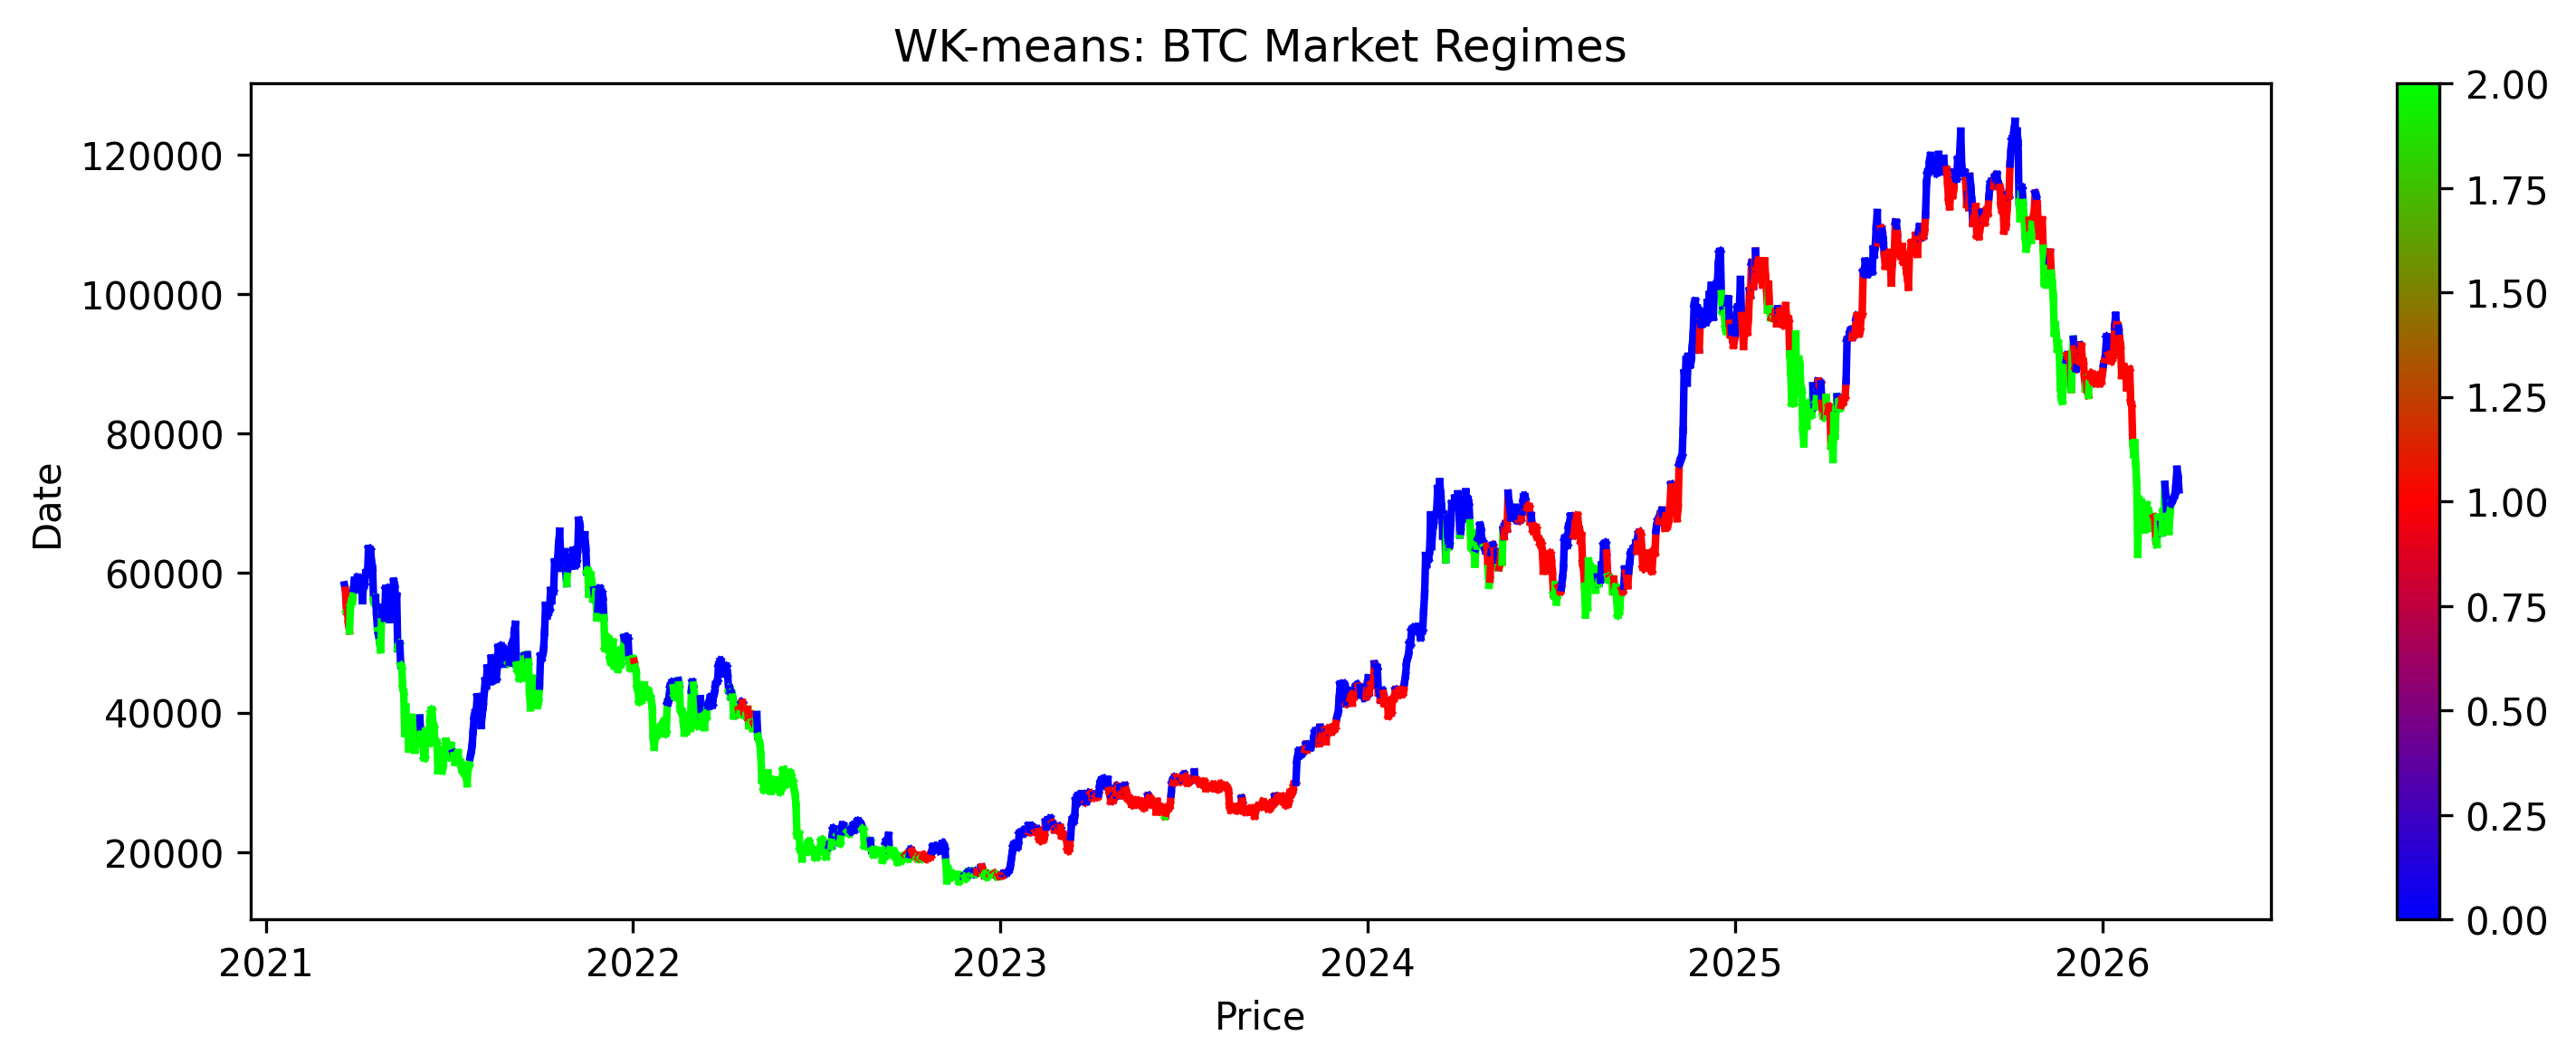

In [10]:
import warnings
warnings.filterwarnings('ignore')

df = pd.concat([df, df_features['wk']], axis=1)

n = len(df)
# Normalize color values for better visualization
norm = plt.Normalize(df['wk'].min(), df['wk'].max())
cmap = plt.cm.brg # Choose a colormap (e.g., 'viridis', 'coolwarm', 'jet')

# Plot line with dynamic coloring
fig, ax = plt.subplots(dpi=300, figsize=(12, 4))
for i in range(0, n - 1):
    ax.plot(df[('Close', 'BTC-USD')][i:i+2], color=cmap(norm(df['wk'][i])), linewidth=2)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)

# Labels and title
ax.set_xlabel("Price")
ax.set_ylabel("Date")
ax.set_title("WK-means: BTC Market Regimes")

plt.show()